In [1]:
import pandas as pd
import torch
import numpy as np
from cgmvae import*
from torch.nn import functional as F
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
# load original input data
# actually we don't really need to do this unless we're interested in accuracy of reconstruction too, but we don't necessarily need to be 
# load latent variables 
latent_features_train = pd.read_csv('/Users/racheliritani/Desktop/AD Project/mm-vae/cfc_pred/shap_analysis/train_df.csv')
latent_features_train

,LV1,LV2,LV3,LV4,LV5,mouse_ids,Diet,Mouse.ID,CFC.24mo.Average
0,1.648254,1.558364,1.450668,1.713205,1.723632,DO-1D-3168,1D,DO-1D-3168,-0.820451
1,-0.794890,-1.137012,-1.105946,-0.938151,-0.875722,DO-40-2083,40,DO-40-2083,0.780704
2,-0.348093,-0.264138,-0.208897,-0.409450,-0.600421,DO-20-1186,20,DO-20-1186,0.452638
3,0.956853,1.063802,1.653756,1.514652,1.608262,DO-1D-3059,1D,DO-1D-3059,1.698389
4,1.407127,1.454008,1.323928,1.397264,1.267337,DO-40-2002,40,DO-40-2002,-0.582971
...,...,...,...,...,...,...,...,...,...
398,-0.890301,-0.859367,-0.897388,-0.965282,-0.967811,DO-1D-3185,1D,DO-1D-3185,-1.763434
399,-0.481943,-0.825826,-0.808517,-0.631954,-0.711390,DO-2D-4058,2D,DO-2D-4058,0.951265
400,1.344620,1.542254,1.234269,1.474108,1.414498,DO-20-1053,20,DO-20-1053,-0.787807
401,0.919085,0.931402,1.518434,1.483853,1.381329,DO-20-1044,20,DO-20-1044,1.624125


In [3]:
data_with_cfc_labels = pd.read_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/data_with_cfc_5bins.csv')
data_with_cfc_labels = data_with_cfc_labels[['MouseID', 'cfc_bin']]
data_with_cfc_labels

,MouseID,cfc_bin
0,DO-40-2162,0
1,DO-40-2179,1
2,DO-40-2181,1
3,DO-40-2187,2
4,DO-40-2099,1
...,...,...
499,DO-2D-4007,1
500,DO-1D-3030,1
501,DO-20-1021,0
502,DO-AL-0002,2


In [4]:
saved_model_path = '/Users/racheliritani/Desktop/AD Project/mm-vae/results_DIET/CGMVAE_cfc_cond_5bins_5dim/saved_model_epoch5000.pth'

In [5]:
accelerator = True 

if accelerator:
    device = torch.device("mps")
else:
    device = torch.device("cpu")

In [6]:
#vae = CGMVAE()
vae = torch.load(saved_model_path, map_location=device)
vae.to(device)
vae.eval()

CGMVAE(
  (label): Embedding(5, 1)
  (fc1): Linear(in_features=37, out_features=16, bias=True)
  (bn1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc21): Linear(in_features=16, out_features=25, bias=True)
  (fc22): Linear(in_features=16, out_features=25, bias=True)
  (fc3): Linear(in_features=6, out_features=16, bias=True)
  (bn3): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc4): Linear(in_features=16, out_features=36, bias=True)
)

## Doing analysis with LV5 conditonal label 0

In [7]:
mouse_ids_0 = data_with_cfc_labels[data_with_cfc_labels['cfc_bin'] == 0]['MouseID'].tolist()
latent_features_train_0 = latent_features_train[latent_features_train['Mouse.ID'].isin(mouse_ids_0)]
latent_features_train_0 = latent_features_train_0[['LV1', 'LV2', 'LV3', 'LV4', 'LV5']]
latent_features_train_0

,LV1,LV2,LV3,LV4,LV5
13,-0.893698,-0.720176,-0.866757,-0.823112,-1.094731
14,-1.622135,-1.356036,-1.420345,-1.495535,-1.267595
23,-0.957110,-0.818695,-0.948691,-0.993643,-0.997910
25,-1.577005,-1.315113,-1.407930,-1.409376,-1.314672
30,-1.276818,-1.093347,-1.127115,-1.167925,-0.975741
...,...,...,...,...,...
388,-1.436359,-1.235382,-1.249746,-1.297314,-0.932213
389,-1.141634,-0.943330,-0.982594,-1.051950,-0.920841
390,-1.327842,-1.144189,-1.166487,-1.188210,-1.019409
394,-1.513083,-1.272883,-1.293408,-1.326203,-1.131958


In [8]:
latent_features_train_mean_0 = latent_features_train_0.mean()
latent_features_train_mean_0

LV1   -1.348009
LV2   -1.133437
LV3   -1.187552
LV4   -1.229302
LV5   -1.090288
dtype: float64

In [9]:
min(latent_features_train_0['LV2']), max(latent_features_train_0['LV2'])

(-1.3861434811169415, -0.2503109067608878)

In [11]:
lv_traversal_values_0 = [-1.6, -1.2, -0.8, -0.4, 0]
latent_features_train_neg2_0 = latent_features_train_mean_0.copy()
latent_features_train_neg2_0.iloc[1] = lv_traversal_values_0[0]
latent_features_train_neg1_0 = latent_features_train_mean_0.copy()
latent_features_train_neg1_0.iloc[1] = lv_traversal_values_0[1]
latent_features_train_zero_0 = latent_features_train_mean_0.copy()
latent_features_train_zero_0.iloc[1] = lv_traversal_values_0[2]
latent_features_train_one_0 = latent_features_train_mean_0.copy()
latent_features_train_one_0.iloc[1] = lv_traversal_values_0[3]
latent_features_train_two_0 = latent_features_train_mean_0.copy()
latent_features_train_two_0.iloc[1] = lv_traversal_values_0[4]

In [12]:
stacked_data_input_0 = np.vstack((latent_features_train_neg2_0, latent_features_train_neg1_0, latent_features_train_zero_0, latent_features_train_one_0, latent_features_train_two_0))
stacked_data_input_0

array([[-1.34800858, -1.6       , -1.18755181, -1.22930228, -1.09028788],
       [-1.34800858, -1.2       , -1.18755181, -1.22930228, -1.09028788],
       [-1.34800858, -0.8       , -1.18755181, -1.22930228, -1.09028788],
       [-1.34800858, -0.4       , -1.18755181, -1.22930228, -1.09028788],
       [-1.34800858,  0.        , -1.18755181, -1.22930228, -1.09028788]])

In [13]:
z_traversal_0 = torch.tensor(stacked_data_input_0, dtype=torch.float32).to(device)
#y_labels = torch.tensor(np.ones(5), dtype=torch.long).to(device)
y_labels_0 = torch.tensor(np.zeros(5), dtype=torch.long).to(device)

## Prepare data for transversing LV5 with conditional label 1

In [14]:
mouse_ids_1 = data_with_cfc_labels[data_with_cfc_labels['cfc_bin'] == 1]['MouseID'].tolist()
latent_features_train_1 = latent_features_train[latent_features_train['Mouse.ID'].isin(mouse_ids_1)]
latent_features_train_1 = latent_features_train_1[['LV1', 'LV2', 'LV3', 'LV4', 'LV5']]
latent_features_train_1

,LV1,LV2,LV3,LV4,LV5
0,1.648254,1.558364,1.450668,1.713205,1.723632
4,1.407127,1.454008,1.323928,1.397264,1.267337
15,1.219892,0.858839,0.811899,0.836143,0.712234
19,1.642225,1.663701,1.346894,1.761315,1.741227
21,1.510944,1.577664,1.146596,1.492334,1.343644
...,...,...,...,...,...
385,1.290042,1.164315,0.996189,1.291856,1.241618
387,1.512038,1.343424,1.239869,1.575708,1.555214
393,1.460973,1.360372,1.296377,1.578111,1.540010
400,1.344620,1.542254,1.234269,1.474108,1.414498


In [15]:
latent_features_train_mean_1 = latent_features_train_1.mean()
latent_features_train_mean_1

LV1    1.338759
LV2    1.337852
LV3    1.042993
LV4    1.238350
LV5    1.175304
dtype: float64

In [17]:
min(latent_features_train_1['LV2']), max(latent_features_train_1['LV2'])

(0.2065224470196836, 1.807766408182176)

In [18]:
lv_traversal_values_1 = [0, 0.5, 1, 1.5, 2]
latent_features_train_neg2_1 = latent_features_train_mean_1.copy()
latent_features_train_neg2_1.iloc[1] = lv_traversal_values_1[0]
latent_features_train_neg1_1 = latent_features_train_mean_1.copy()
latent_features_train_neg1_1.iloc[1] = lv_traversal_values_1[1]
latent_features_train_zero_1 = latent_features_train_mean_1.copy()
latent_features_train_zero_1.iloc[1] = lv_traversal_values_1[2]
latent_features_train_one_1 = latent_features_train_mean_1.copy()
latent_features_train_one_1.iloc[1] = lv_traversal_values_1[3]
latent_features_train_two_1 = latent_features_train_mean_1.copy()
latent_features_train_two_1.iloc[1] = lv_traversal_values_1[4]

In [19]:
stacked_data_input_1 = np.vstack((latent_features_train_neg2_1, latent_features_train_neg1_1, latent_features_train_zero_1, latent_features_train_one_1, latent_features_train_two_1))
stacked_data_input_1

array([[1.33875905, 0.        , 1.04299338, 1.23834988, 1.17530418],
       [1.33875905, 0.5       , 1.04299338, 1.23834988, 1.17530418],
       [1.33875905, 1.        , 1.04299338, 1.23834988, 1.17530418],
       [1.33875905, 1.5       , 1.04299338, 1.23834988, 1.17530418],
       [1.33875905, 2.        , 1.04299338, 1.23834988, 1.17530418]])

In [20]:
z_traversal_1 = torch.tensor(stacked_data_input_1, dtype=torch.float32).to(device)
y_labels_1 = torch.tensor(np.ones(5), dtype=torch.long).to(device)

# Prepare data for traversing LV5 with conditional label 2

In [22]:
mouse_ids_2 = data_with_cfc_labels[data_with_cfc_labels['cfc_bin'] == 2]['MouseID'].tolist()
latent_features_train_2 = latent_features_train[latent_features_train['Mouse.ID'].isin(mouse_ids_2)]
latent_features_train_2 = latent_features_train_2[['LV1', 'LV2', 'LV3', 'LV4', 'LV5']]
latent_features_train_2

,LV1,LV2,LV3,LV4,LV5
2,-0.348093,-0.264138,-0.208897,-0.409450,-0.600421
5,0.035996,0.163485,0.447772,0.348364,0.387066
7,0.014778,-0.089215,0.067121,-0.068191,-0.177578
10,-0.055891,-0.020498,0.081582,-0.034955,-0.152137
11,0.142019,0.236467,0.418668,0.282368,0.217389
...,...,...,...,...,...
370,-0.149577,-0.281372,-0.351628,-0.525232,-0.632906
380,-0.082595,-0.111938,0.116845,-0.013294,0.003919
382,-0.117836,-0.044868,-0.031371,-0.131411,-0.181905
395,-0.126171,-0.197896,-0.105915,-0.251575,-0.388558


In [23]:
latent_features_train_mean_2 = latent_features_train_2.mean()
latent_features_train_mean_2

LV1   -0.110642
LV2   -0.064196
LV3    0.047799
LV4   -0.086370
LV5   -0.156310
dtype: float64

In [24]:
min(latent_features_train_2['LV2']), max(latent_features_train_2['LV2'])

(-0.5547594161363418, 0.4960971993747907)

In [29]:
lv_traversal_values_2 = [-1, -0.5, 0, 0.5, 1]
latent_features_train_neg2_2 = latent_features_train_mean_2.copy()
latent_features_train_neg2_2.iloc[1] = lv_traversal_values_2[0]
latent_features_train_neg1_2 = latent_features_train_mean_2.copy()
latent_features_train_neg1_2.iloc[1] = lv_traversal_values_2[1]
latent_features_train_zero_2 = latent_features_train_mean_2.copy()
latent_features_train_zero_2.iloc[1] = lv_traversal_values_2[2]
latent_features_train_one_2 = latent_features_train_mean_2.copy()
latent_features_train_one_2.iloc[1] = lv_traversal_values_2[3]
latent_features_train_two_2 = latent_features_train_mean_2.copy()
latent_features_train_two_2.iloc[1] = lv_traversal_values_2[4]

In [30]:
stacked_data_input_2 = np.vstack((latent_features_train_neg2_2, latent_features_train_neg1_2, latent_features_train_zero_2, latent_features_train_one_2, latent_features_train_two_2))
stacked_data_input_2

array([[-0.11064207, -1.        ,  0.0477987 , -0.08637038, -0.15630968],
       [-0.11064207, -0.5       ,  0.0477987 , -0.08637038, -0.15630968],
       [-0.11064207,  0.        ,  0.0477987 , -0.08637038, -0.15630968],
       [-0.11064207,  0.5       ,  0.0477987 , -0.08637038, -0.15630968],
       [-0.11064207,  1.        ,  0.0477987 , -0.08637038, -0.15630968]])

In [31]:
z_traversal_2 = torch.tensor(stacked_data_input_2, dtype=torch.float32).to(device)
y_labels_2 = torch.tensor(np.ones(5) * 2, dtype=torch.long).to(device)

# Prepare data for traversing LV5 with conditional label 3

In [32]:
mouse_ids_3 = data_with_cfc_labels[data_with_cfc_labels['cfc_bin'] == 3]['MouseID'].tolist()
latent_features_train_3 = latent_features_train[latent_features_train['Mouse.ID'].isin(mouse_ids_3)]
latent_features_train_3 = latent_features_train_3[['LV1', 'LV2', 'LV3', 'LV4', 'LV5']]
latent_features_train_3

,LV1,LV2,LV3,LV4,LV5
1,-0.794890,-1.137012,-1.105946,-0.938151,-0.875722
6,-0.577949,-0.922756,-0.905568,-0.737581,-0.774369
8,-0.475260,-0.876369,-0.796801,-0.632104,-0.687762
16,-0.541115,-0.852015,-0.859629,-0.709350,-0.757850
26,-0.231526,-0.615353,-0.641229,-0.464054,-0.702358
...,...,...,...,...,...
377,-0.056066,-0.411063,-0.400782,-0.268354,-0.583646
379,-0.888835,-1.038130,-1.258650,-1.086238,-1.199128
386,-0.406040,-0.840978,-0.788157,-0.581329,-0.696034
397,-0.521439,-0.892044,-0.884971,-0.669015,-0.744653


In [33]:
latent_features_train_mean_3 = latent_features_train_3.mean()
latent_features_train_mean_3

LV1   -0.560520
LV2   -0.896860
LV3   -0.899536
LV4   -0.714436
LV5   -0.797925
dtype: float64

In [34]:
min(latent_features_train_3['LV2']), max(latent_features_train_3['LV2'])

(-1.2109654257606155, -0.4035789471840946)

In [35]:
lv_traversal_values_3 = [-1.4, -1.1, -0.8, -0.5, -0.2]
latent_features_train_neg2_3 = latent_features_train_mean_3.copy()
latent_features_train_neg2_3.iloc[1] = lv_traversal_values_3[0]
latent_features_train_neg1_3 = latent_features_train_mean_3.copy()
latent_features_train_neg1_3.iloc[1] = lv_traversal_values_3[1]
latent_features_train_zero_3 = latent_features_train_mean_3.copy()
latent_features_train_zero_3.iloc[1] = lv_traversal_values_3[2]
latent_features_train_one_3 = latent_features_train_mean_3.copy()
latent_features_train_one_3.iloc[1] = lv_traversal_values_3[3]
latent_features_train_two_3 = latent_features_train_mean_3.copy()
latent_features_train_two_3.iloc[1] = lv_traversal_values_3[4]

In [36]:
stacked_data_input_3 = np.vstack((latent_features_train_neg2_3, latent_features_train_neg1_3, latent_features_train_zero_3, latent_features_train_one_3, latent_features_train_two_3))
stacked_data_input_3

array([[-0.56051965, -1.4       , -0.89953568, -0.71443556, -0.79792473],
       [-0.56051965, -1.1       , -0.89953568, -0.71443556, -0.79792473],
       [-0.56051965, -0.8       , -0.89953568, -0.71443556, -0.79792473],
       [-0.56051965, -0.5       , -0.89953568, -0.71443556, -0.79792473],
       [-0.56051965, -0.2       , -0.89953568, -0.71443556, -0.79792473]])

In [37]:
z_traversal_3 = torch.tensor(stacked_data_input_3, dtype=torch.float32).to(device)
y_labels_3 = torch.tensor(np.ones(5) * 3, dtype=torch.long).to(device)

# Prepare data for traversing LV5 with conditional label 4

In [38]:
mouse_ids_4 = data_with_cfc_labels[data_with_cfc_labels['cfc_bin'] == 4]['MouseID'].tolist()
latent_features_train_4 = latent_features_train[latent_features_train['Mouse.ID'].isin(mouse_ids_4)]
latent_features_train_4 = latent_features_train_4[['LV1', 'LV2', 'LV3', 'LV4', 'LV5']]

In [39]:
latent_features_train_mean_4 = latent_features_train_4.mean()
latent_features_train_mean_4

LV1    0.930291
LV2    1.044031
LV3    1.538322
LV4    1.168438
LV5    1.401014
dtype: float64

In [40]:
min(latent_features_train_4['LV2']), max(latent_features_train_4['LV2'])

(0.734290166588603, 1.1486910311916485)

In [41]:
lv_traversal_values_4 = [0.5, 0.7, 0.9, 1.1, 1.3]
latent_features_train_neg2_4 = latent_features_train_mean_4.copy()
latent_features_train_neg2_4.iloc[1] = lv_traversal_values_4[0]
latent_features_train_neg1_4 = latent_features_train_mean_4.copy()
latent_features_train_neg1_4.iloc[1] = lv_traversal_values_4[1]
latent_features_train_zero_4 = latent_features_train_mean_4.copy()
latent_features_train_zero_4.iloc[1] = lv_traversal_values_4[2]
latent_features_train_one_4 = latent_features_train_mean_4.copy()
latent_features_train_one_4.iloc[1] = lv_traversal_values_4[3]
latent_features_train_two_4 = latent_features_train_mean_4.copy()
latent_features_train_two_4.iloc[1] = lv_traversal_values_4[4]

In [44]:
stacked_data_input_4 = np.vstack((latent_features_train_neg2_4, latent_features_train_neg1_4, latent_features_train_zero_4, latent_features_train_one_4, latent_features_train_two_4))
stacked_data_input_4

array([[0.93029123, 0.5       , 1.53832194, 1.16843782, 1.40101444],
       [0.93029123, 0.7       , 1.53832194, 1.16843782, 1.40101444],
       [0.93029123, 0.9       , 1.53832194, 1.16843782, 1.40101444],
       [0.93029123, 1.1       , 1.53832194, 1.16843782, 1.40101444],
       [0.93029123, 1.3       , 1.53832194, 1.16843782, 1.40101444]])

In [45]:
z_traversal_4 = torch.tensor(stacked_data_input_4, dtype=torch.float32).to(device)
y_labels_4 = torch.tensor(np.ones(5) * 4, dtype=torch.long).to(device)

# Get mean and std for unstandardizing 

In [46]:
# Using training data to extract the mean and standardizing for our "unstandardizing"
cgmvae_train_data = pd.read_csv('/Users/racheliritani/Desktop/AD Project/VAE-work/c-gmvae/train_data_with_cfc_5bins.csv')
cgmvae_train_data_features = cgmvae_train_data.iloc[:, 1:-5]
cgmvae_train_data_features

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,28,1557,30.432753,23.594599,23.529931,161.043852,71.901384,69.226421,495.841743,501.256947,...,1.822722,0.348339,0.747802,291.910043,181.741358,208.833723,0.183285,0.231782,0.235033,1
1,28,1520,25.977819,29.254446,30.242503,127.747193,85.358891,71.148922,466.210754,464.586935,...,0.999795,1.146192,0.924488,145.679543,223.139358,208.833223,0.106295,0.174654,0.216059,1
2,26,1638,24.242912,23.626717,22.912834,166.520150,72.692867,59.960123,464.789558,574.873297,...,1.044482,1.776962,2.179152,261.760471,173.953709,153.357082,0.110173,0.155822,0.285573,1
3,28,1406,24.467278,25.248257,23.109300,164.713839,87.471495,73.518078,467.014292,562.596065,...,1.680998,0.523920,0.894472,172.757669,113.888445,116.420115,0.104875,0.186652,0.231596,1
4,27,1463,27.809766,25.863157,26.732366,158.296170,79.935074,89.493029,460.859469,452.538921,...,1.255751,1.035345,0.902079,232.284376,238.633857,250.015922,0.106669,0.199779,0.104132,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
398,22,825,26.553743,38.871831,38.162515,88.072095,132.803099,261.476515,457.706405,636.333799,...,1.327876,-0.250994,-2.736010,144.637287,200.397753,58.352082,0.301015,0.221042,0.555556,5
399,22,811,29.286695,34.668011,28.691245,145.238675,123.017597,261.476515,487.109521,459.643424,...,0.292768,1.503025,-2.736010,122.680287,147.980753,58.352082,0.301015,0.193995,0.555556,4
400,22,790,20.955567,32.435192,67.590983,135.481563,148.935317,261.476515,471.297011,513.299191,...,-0.505758,2.390828,-2.736010,128.851073,144.305810,58.352082,0.301015,0.188242,0.555556,4
401,22,748,24.315156,29.916707,67.590983,139.326564,136.439061,261.476515,544.317015,474.787570,...,3.246833,0.934841,-2.736010,223.713073,138.051810,58.352082,0.301015,0.082493,0.555556,4


In [47]:
all_input_features = cgmvae_train_data_features.columns
all_input_features

Index(['Generation', 'SurvDays', 'Y1A_BW_BW', 'Y2A_BW_BW', 'Y3A_BW_BW',
       'Y1_Glu.F_Glucose', 'Y2_Glu.F_Glucose', 'Y3_Glu.F_Glucose',
       'Y1_Echo_BPM', 'Y2_Echo_BPM', 'Y3_Echo_BPM', 'Y1_Echo_CardiacOutput',
       'Y2_Echo_CardiacOutput', 'Y3_Echo_CardiacOutput', 'Y1_CBC_Hgb',
       'Y2_CBC_Hgb', 'Y3_CBC_Hgb', 'Y1_Rotarod_Mean', 'Y2_Rotarod_Mean',
       'Y3_Rotarod_Mean', 'Y1_AS_MeanLog', 'Y2_AS_MeanLog', 'Y3_AS_MeanLog',
       'Y1_Wheel_AvgSpeedLFC', 'Y2_Wheel_AvgSpeedLFC', 'Y3_Wheel_AvgSpeedLFC',
       'Y1_Wheel_AvgDistLFC', 'Y2_Wheel_AvgDistLFC', 'Y3_Wheel_AvgDistLFC',
       'Y1A_Grip_All', 'Y2A_Grip_All', 'Y3A_Grip_All',
       'Y1A_Frailty_FrailtyAdj', 'Y2A_Frailty_FrailtyAdj',
       'Y3A_Frailty_FrailtyAdj', 'Diet_num'],
      dtype='object')

In [48]:
col_means = cgmvae_train_data_features.mean()
col_means.shape

(36,)

In [50]:
col_std = cgmvae_train_data_features.std()
col_std.shape

(36,)

# Run decoding on each conditional feature 

In [51]:
with torch.no_grad():
    # y_emb = vae.label(y_labels)

    # x = torch.cat((z_traversal, y_emb), dim=1)

    # h3_linear = vae.fc3(x)
    # h3_bn = vae.bn3(h3_linear)
    # h3_act = F.tanh(h3_bn)
    
    # vae.fc4(h3_act)
    reconstructions_standardized_0 = vae.decode(z_traversal_0, y_labels_0)
    reconstructions_standardized_1 = vae.decode(z_traversal_1, y_labels_1)
    reconstructions_standardized_2 = vae.decode(z_traversal_2, y_labels_2)
    reconstructions_standardized_3 = vae.decode(z_traversal_3, y_labels_3)
    reconstructions_standardized_4 = vae.decode(z_traversal_4, y_labels_4)

In [52]:
col_means_tensor = torch.tensor(col_means.values, dtype=torch.float32).to(device)
col_std_tensor = torch.tensor(col_std.values, dtype=torch.float32).to(device)

# Doing analysis for LV5 traversal with conditional label 0

In [53]:
unstandardized_data_tensor_0 = reconstructions_standardized_0 * col_std_tensor
unstandardized_data_tensor_0 = unstandardized_data_tensor_0 + col_means_tensor

In [54]:
reconstructions_unstandardized_df_0 = pd.DataFrame(unstandardized_data_tensor_0.cpu(), columns=all_input_features)
reconstructions_unstandardized_df_0

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,24.182301,1011.225342,29.244316,39.607155,37.036476,192.746185,152.985214,159.483322,542.203125,538.587158,...,1.963323,1.440043,-1.171089,171.343277,177.576340,133.768982,0.188058,0.222390,0.307909,3.381516
1,24.169220,1011.978943,29.246658,39.600227,36.996567,192.670670,152.950714,159.261383,542.227844,538.640808,...,1.964996,1.440387,-1.164548,171.185822,177.544434,133.898727,0.188403,0.222435,0.307430,3.379792
2,24.156321,1012.730469,29.248632,39.593231,36.957443,192.594772,152.915390,159.040985,542.252625,538.690918,...,1.966626,1.440647,-1.157953,171.026901,177.513046,134.025803,0.188738,0.222478,0.306954,3.378058
3,24.143593,1013.480713,29.250250,39.586140,36.919044,192.518478,152.879120,158.821869,542.277405,538.737488,...,1.968214,1.440823,-1.151303,170.866425,177.482147,134.150299,0.189066,0.222520,0.306482,3.376308
4,24.131031,1014.230225,29.251522,39.578934,36.881321,192.441772,152.841751,158.603775,542.302063,538.780396,...,1.969759,1.440913,-1.144595,170.704300,177.451675,134.272324,0.189385,0.222560,0.306011,3.374535


In [55]:
reconstructions_standardized_df_0 = pd.DataFrame(reconstructions_standardized_0.cpu(), columns=all_input_features)
reconstructions_standardized_df_0

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,-0.410860,0.019666,0.656357,0.790129,0.123957,1.024269,0.706056,0.109147,0.719664,0.760444,...,0.186150,0.095705,0.139334,-0.428913,0.246407,0.177791,0.475541,0.600756,0.000489,0.408736
1,-0.416582,0.023936,0.656849,0.789319,0.121037,1.022191,0.705129,0.106029,0.720149,0.761536,...,0.187417,0.095928,0.142746,-0.432644,0.245531,0.180544,0.479960,0.601730,-0.002976,0.407484
2,-0.422225,0.028194,0.657264,0.788500,0.118175,1.020103,0.704181,0.102933,0.720636,0.762555,...,0.188652,0.096097,0.146185,-0.436411,0.244670,0.183240,0.484267,0.602673,-0.006416,0.406225
3,-0.427792,0.032445,0.657604,0.787670,0.115365,1.018003,0.703207,0.099855,0.721122,0.763503,...,0.189854,0.096212,0.149653,-0.440214,0.243821,0.185881,0.488468,0.603581,-0.009834,0.404953
4,-0.433286,0.036691,0.657872,0.786826,0.112605,1.015892,0.702203,0.096791,0.721606,0.764376,...,0.191024,0.096271,0.153151,-0.444056,0.242985,0.188470,0.492567,0.604455,-0.013233,0.403665


In [56]:
z_min = reconstructions_standardized_df_0.iloc[0]
z_max = reconstructions_standardized_df_0.iloc[-1]
difference_lv5_0 = np.abs(z_max - z_min)
difference_lv5_0_ranked = difference_lv5_0.sort_values(ascending=False)
difference_lv5_0_ranked.head(10)

Generation                0.022426
Y1A_Frailty_FrailtyAdj    0.017026
SurvDays                  0.017025
Y1A_Grip_All              0.015144
Y3_Wheel_AvgSpeedLFC      0.015076
Y3_Echo_CardiacOutput     0.014308
Y3_Wheel_AvgDistLFC       0.013817
Y3A_Frailty_FrailtyAdj    0.013723
Y3_AS_MeanLog             0.013673
Y3_CBC_Hgb                0.012366
dtype: float32

In [57]:
difference_lv5_0_test = np.abs(reconstructions_standardized_df_0.iloc[-1, [0, 1]] - reconstructions_standardized_df_0.iloc[0, [0, 1]])
difference_lv5_0_test = pd.concat([difference_lv5_0_test, np.abs(reconstructions_standardized_df_0.iloc[-1, [-1]] - reconstructions_standardized_df_0.iloc[0, [-1]])])
difference_lv5_0_test
max_data = reconstructions_standardized_df_0.iloc[-1, 2:-1]
min_data = reconstructions_standardized_df_0.iloc[0, 2:-1]

In [58]:
len(max_data) / 3

11.0

In [59]:
max_data

Y1A_BW_BW                 0.657872
Y2A_BW_BW                 0.786826
Y3A_BW_BW                 0.112605
Y1_Glu.F_Glucose          1.015892
Y2_Glu.F_Glucose          0.702203
Y3_Glu.F_Glucose          0.096791
Y1_Echo_BPM               0.721606
Y2_Echo_BPM               0.764376
Y3_Echo_BPM              -0.009324
Y1_Echo_CardiacOutput     0.951645
Y2_Echo_CardiacOutput     0.674578
Y3_Echo_CardiacOutput    -0.077135
Y1_CBC_Hgb                0.250003
Y2_CBC_Hgb               -0.862474
Y3_CBC_Hgb                0.094808
Y1_Rotarod_Mean          -0.615530
Y2_Rotarod_Mean          -0.899771
Y3_Rotarod_Mean          -0.135585
Y1_AS_MeanLog             0.027976
Y2_AS_MeanLog             0.087821
Y3_AS_MeanLog            -0.314821
Y1_Wheel_AvgSpeedLFC      0.194377
Y2_Wheel_AvgSpeedLFC      0.097175
Y3_Wheel_AvgSpeedLFC      0.184276
Y1_Wheel_AvgDistLFC       0.191024
Y2_Wheel_AvgDistLFC       0.096271
Y3_Wheel_AvgDistLFC       0.153151
Y1A_Grip_All             -0.444056
Y2A_Grip_All        

In [60]:
feature_names = max_data.index.tolist()
max_data_np = max_data.to_numpy()
min_data_np = min_data.to_numpy()
for feature in range(int(len(max_data) / 3)): 
    feature_name = feature_names[feature*3]
    feature_name = feature_name.split('_', 1)[1]
    max_vector = max_data_np[feature:feature+3]
    min_vector = min_data_np[feature:feature+3]
    diff = np.abs(max_vector-min_vector)
    sum = np.linalg.norm(diff)
    difference_lv5_0_test = pd.concat([difference_lv5_0_test, pd.Series(data=sum, index=[feature_name])])

In [61]:
print(difference_lv5_0_test)

Generation            0.022426
SurvDays              0.017025
Diet_num              0.005071
BW_BW                 0.011920
Glu.F_Glucose         0.014490
Echo_BPM              0.014625
Echo_CardiacOutput    0.015417
CBC_Hgb               0.013087
Rotarod_Mean          0.013111
AS_MeanLog            0.011406
Wheel_AvgSpeedLFC     0.012444
Wheel_AvgDistLFC      0.013946
Grip_All              0.016981
Frailty_FrailtyAdj    0.019932
dtype: float32


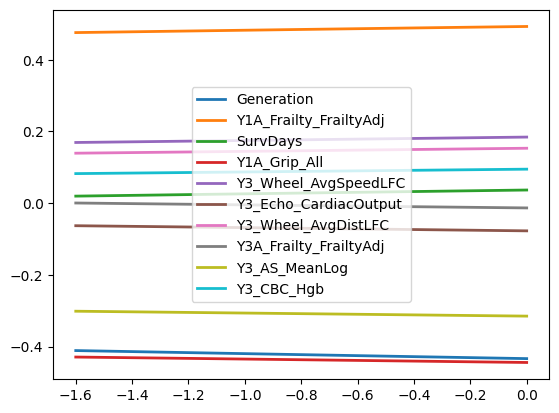

In [62]:
for col_name in difference_lv5_0_ranked.head(10).index.tolist(): 
    plt.plot(
        lv_traversal_values_0, 
        reconstructions_standardized_df_0[col_name], 
        label=col_name, 
        linewidth=2
    )
    plt.legend()

# Doing analysis for LV5 traversal with conditional label 1

In [63]:
unstandardized_data_tensor_1 = reconstructions_standardized_1 * col_std_tensor
unstandardized_data_tensor_1 = unstandardized_data_tensor_1 + col_means_tensor

In [64]:
reconstructions_unstandardized_df_1 = pd.DataFrame(unstandardized_data_tensor_1.cpu(), columns=all_input_features)
reconstructions_unstandardized_df_1

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,22.247698,1135.520630,27.068666,32.455982,25.963451,162.589554,117.148529,118.179352,498.800079,518.546814,...,1.495711,1.342744,-0.367158,149.506805,173.333740,135.142914,0.263422,0.200069,0.260424,2.636912
1,22.241646,1137.406372,27.106503,32.419689,25.883669,162.689835,116.824890,117.566963,498.614380,518.256775,...,1.494510,1.331769,-0.358130,149.258179,173.287628,135.320343,0.264099,0.199895,0.259288,2.618487
2,22.233168,1139.598267,27.139006,32.372654,25.787663,162.723358,116.454407,116.851349,498.356415,517.920410,...,1.492760,1.320667,-0.346008,148.951721,173.234970,135.541397,0.264820,0.199704,0.257940,2.598785
3,22.222519,1142.044189,27.166803,32.316883,25.678795,162.701645,116.045036,116.052475,498.043243,517.546082,...,1.490577,1.309400,-0.331231,148.592529,173.176666,135.794632,0.265574,0.199500,0.256423,2.578062
4,22.209906,1144.702881,27.190401,32.253941,25.559692,162.633835,115.603050,115.186050,497.688202,517.140564,...,1.488050,1.297940,-0.314153,148.184814,173.113449,136.071091,0.266358,0.199285,0.254770,2.556518


In [65]:
reconstructions_standardized_df_1 = pd.DataFrame(reconstructions_standardized_1.cpu(), columns=all_input_features)
reconstructions_standardized_df_1

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,-1.257088,0.723903,0.199177,-0.047013,-0.686230,0.194458,-0.256255,-0.471078,-0.132313,0.352714,...,-0.167994,0.032457,0.558591,-0.946440,0.129976,0.206941,1.442376,0.114265,-0.342811,-0.132173
1,-1.259735,0.734587,0.207128,-0.051261,-0.692068,0.197218,-0.264945,-0.479681,-0.135958,0.346814,...,-0.168903,0.025323,0.563299,-0.952332,0.128711,0.210705,1.451068,0.110472,-0.351023,-0.145558
2,-1.263444,0.747006,0.213958,-0.056767,-0.699092,0.198140,-0.274893,-0.489733,-0.141022,0.339969,...,-0.170228,0.018106,0.569620,-0.959595,0.127266,0.215395,1.460306,0.106318,-0.360767,-0.159870
3,-1.268102,0.760864,0.219799,-0.063296,-0.707058,0.197543,-0.285886,-0.500956,-0.147169,0.332354,...,-0.171881,0.010782,0.577327,-0.968108,0.125665,0.220768,1.469990,0.101868,-0.371736,-0.174924
4,-1.273619,0.775928,0.224758,-0.070664,-0.715772,0.195677,-0.297755,-0.513127,-0.154138,0.324104,...,-0.173795,0.003332,0.586233,-0.977771,0.123930,0.226634,1.480043,0.097173,-0.383689,-0.190574


In [66]:
z_min = reconstructions_standardized_df_1.iloc[0]
z_max = reconstructions_standardized_df_1.iloc[-1]
difference_lv5_1 = np.abs(z_max - z_min)
difference_lv5_1_ranked = difference_lv5_1.sort_values(ascending=False)
difference_lv5_1_ranked.head(10)

Y3_Echo_CardiacOutput     0.058461
Diet_num                  0.058401
Y3_Echo_BPM               0.054829
SurvDays                  0.052025
Y3_Rotarod_Mean           0.045364
Y3_Glu.F_Glucose          0.042049
Y2_Glu.F_Glucose          0.041500
Y3_Wheel_AvgSpeedLFC      0.041468
Y3A_Frailty_FrailtyAdj    0.040878
Y1A_Frailty_FrailtyAdj    0.037668
dtype: float32

# Doing analysis for LV5 traversal with conditional label 2

In [67]:
unstandardized_data_tensor_2 = reconstructions_standardized_2 * col_std_tensor
unstandardized_data_tensor_2 = unstandardized_data_tensor_2 + col_means_tensor

In [68]:
reconstructions_unstandardized_df_2 = pd.DataFrame(unstandardized_data_tensor_2.cpu(), columns=all_input_features)
reconstructions_unstandardized_df_2

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,22.847300,1102.932129,27.971134,34.060017,28.014534,170.582565,124.993629,127.544289,504.237000,523.226562,...,1.564969,1.378784,-0.720450,160.785492,175.067230,136.158066,0.250495,0.204279,0.273864,2.771952
1,22.836033,1104.703613,27.984222,34.018635,27.932154,170.526642,124.710892,126.971443,504.064789,522.993042,...,1.564153,1.371735,-0.708534,160.481842,175.014191,136.336243,0.251040,0.204142,0.272752,2.758438
2,22.823357,1106.630005,27.994318,33.972240,27.842976,170.439209,124.404114,126.351028,503.865417,522.735901,...,1.563088,1.364448,-0.694920,160.140579,174.957657,136.528534,0.251605,0.203995,0.271545,2.744299
3,22.809357,1108.693359,28.001684,33.921509,27.748119,170.324570,124.075920,125.689766,503.644806,522.457947,...,1.561815,1.356904,-0.679766,159.763519,174.897888,136.731003,0.252187,0.203842,0.270258,2.729613
4,22.794106,1110.880859,28.006535,33.866947,27.648411,170.185913,123.728226,124.992599,503.407379,522.161438,...,1.560364,1.349088,-0.663193,159.352036,174.835068,136.940735,0.252786,0.203680,0.268901,2.714435


In [69]:
reconstructions_standardized_df_2 = pd.DataFrame(reconstructions_standardized_2.cpu(), columns=all_input_features)
reconstructions_standardized_df_2

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,-0.994812,0.539262,0.388817,0.140761,-0.536157,0.414400,-0.045593,-0.339522,-0.025590,0.447927,...,-0.115541,0.055884,0.374346,-0.679133,0.177548,0.228479,1.276543,0.206020,-0.245643,-0.034075
1,-0.999740,0.549299,0.391567,0.135917,-0.542185,0.412861,-0.053185,-0.347569,-0.028970,0.443175,...,-0.116159,0.051302,0.380560,-0.686330,0.176093,0.232259,1.283531,0.203026,-0.253687,-0.043892
2,-1.005286,0.560213,0.393689,0.130486,-0.548710,0.410455,-0.061423,-0.356285,-0.032883,0.437943,...,-0.116966,0.046565,0.387660,-0.694418,0.174541,0.236339,1.290774,0.199841,-0.262413,-0.054163
3,-1.011409,0.571904,0.395237,0.124547,-0.555650,0.407300,-0.070236,-0.365574,-0.037213,0.432289,...,-0.117930,0.041661,0.395563,-0.703354,0.172901,0.240635,1.298244,0.196486,-0.271716,-0.064831
4,-1.018080,0.584298,0.396256,0.118160,-0.562945,0.403485,-0.079572,-0.375368,-0.041875,0.426255,...,-0.119029,0.036581,0.404206,-0.713106,0.171177,0.245084,1.305923,0.192976,-0.281521,-0.075857


In [70]:
z_min = reconstructions_standardized_df_2.iloc[0]
z_max = reconstructions_standardized_df_2.iloc[-1]
difference_lv5_2 = np.abs(z_max - z_min)
difference_lv5_2_ranked = difference_lv5_2.sort_values(ascending=False)
difference_lv5_2_ranked.head(10)

Y3_Echo_CardiacOutput     0.049625
Y3_Echo_BPM               0.046062
SurvDays                  0.045036
Diet_num                  0.041782
Y3_Rotarod_Mean           0.039538
Y3_Wheel_AvgSpeedLFC      0.038701
Y3A_Frailty_FrailtyAdj    0.035878
Y3_Glu.F_Glucose          0.035845
Y2_Glu.F_Glucose          0.033980
Y1A_Grip_All              0.033973
dtype: float32

# Doing analysis for LV5 traversal with conditional label 3

In [71]:
unstandardized_data_tensor_3 = reconstructions_standardized_3 * col_std_tensor
unstandardized_data_tensor_3 = unstandardized_data_tensor_3 + col_means_tensor

In [72]:
reconstructions_unstandardized_df_3 = pd.DataFrame(unstandardized_data_tensor_3.cpu(), columns=all_input_features)
reconstructions_unstandardized_df_3

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,23.827385,1037.471069,28.921988,37.783699,33.815052,185.410873,143.955093,149.518524,527.874268,533.997498,...,1.815511,1.437547,-1.120059,171.709839,177.273544,135.028091,0.209893,0.215864,0.299296,3.192298
1,23.820028,1038.046753,28.925137,37.774426,33.783775,185.370102,143.904175,149.333603,527.872559,533.993958,...,1.816410,1.437002,-1.115663,171.602386,177.247772,135.121414,0.210114,0.215863,0.298895,3.189665
2,23.812630,1038.631470,28.927916,37.764900,33.752575,185.327347,143.851593,149.146912,527.870117,533.987732,...,1.817280,1.436393,-1.111117,171.491058,177.222076,135.213837,0.210333,0.215861,0.298491,3.186999
3,23.805191,1039.225342,28.930336,37.755119,33.721443,185.282700,143.797333,148.958374,527.867004,533.978821,...,1.818120,1.435719,-1.106423,171.375885,177.196426,135.305389,0.210550,0.215858,0.298084,3.184298
4,23.797707,1039.828491,28.932404,37.745087,33.690365,185.236176,143.741348,148.767944,527.863098,533.967224,...,1.818932,1.434979,-1.101582,171.256805,177.170822,135.395996,0.210765,0.215855,0.297674,3.181559


In [73]:
reconstructions_standardized_df_3 = pd.DataFrame(reconstructions_standardized_3.cpu(), columns=all_input_features)
reconstructions_standardized_df_3

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,-0.566106,0.168370,0.588625,0.576669,-0.111747,0.822425,0.463573,-0.030835,0.438397,0.667066,...,0.074205,0.094083,0.165947,-0.420225,0.238097,0.204505,0.755652,0.458509,-0.061779,0.271281
1,-0.569324,0.171632,0.589286,0.575583,-0.114035,0.821303,0.462206,-0.033433,0.438364,0.666994,...,0.074887,0.093728,0.168239,-0.422771,0.237390,0.206485,0.758494,0.458489,-0.064679,0.269368
2,-0.572560,0.174945,0.589870,0.574468,-0.116318,0.820127,0.460794,-0.036056,0.438316,0.666867,...,0.075545,0.093332,0.170610,-0.425410,0.236685,0.208446,0.761305,0.458451,-0.067601,0.267432
3,-0.575814,0.178309,0.590379,0.573324,-0.118596,0.818898,0.459337,-0.038704,0.438254,0.666686,...,0.076182,0.092894,0.173058,-0.428140,0.235981,0.210388,0.764087,0.458395,-0.070545,0.265469
4,-0.579088,0.181727,0.590813,0.572149,-0.120870,0.817618,0.457833,-0.041379,0.438178,0.666450,...,0.076797,0.092413,0.175583,-0.430962,0.235278,0.212311,0.766841,0.458319,-0.073511,0.263480


In [74]:
z_min = reconstructions_standardized_df_3.iloc[0]
z_max = reconstructions_standardized_df_3.iloc[-1]
difference_lv5_3 = np.abs(z_max - z_min)
difference_lv5_3_ranked = difference_lv5_3.sort_values(ascending=False)
difference_lv5_3_ranked.head(10)

SurvDays                  0.013357
Generation                0.012982
Y3_Echo_CardiacOutput     0.012425
Y3A_Frailty_FrailtyAdj    0.011732
Y3_Wheel_AvgSpeedLFC      0.011508
Y1A_Frailty_FrailtyAdj    0.011188
Y1A_Grip_All              0.010737
Y3_Glu.F_Glucose          0.010544
Y3_Echo_BPM               0.010096
Y3_Wheel_AvgDistLFC       0.009636
dtype: float32

# Doing analysis for LV5 traversal with conditional label 4

In [75]:
unstandardized_data_tensor_4 = reconstructions_standardized_4 * col_std_tensor
unstandardized_data_tensor_4 = unstandardized_data_tensor_4 + col_means_tensor

In [76]:
reconstructions_unstandardized_df_4 = pd.DataFrame(unstandardized_data_tensor_4.cpu(), columns=all_input_features)
reconstructions_unstandardized_df_4

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,23.781525,1029.654541,28.964521,37.993729,35.390038,188.681564,143.792175,153.808960,528.563660,532.759766,...,1.796206,1.422594,-1.039289,164.567352,176.594467,130.511292,0.206583,0.218096,0.307475,3.183966
1,23.773623,1030.072632,28.968584,37.988792,35.363174,188.645264,143.771622,153.676239,528.568176,532.798828,...,1.797200,1.423279,-1.036307,164.493439,176.571671,130.598328,0.206826,0.218122,0.307192,3.182807
2,23.765772,1030.489136,28.972504,37.983906,35.336655,188.608765,143.751205,153.544510,528.573059,532.837158,...,1.798184,1.423944,-1.033304,164.419067,176.549149,130.684402,0.207065,0.218147,0.306911,3.181663
3,23.757975,1030.903809,28.976282,37.979073,35.310474,188.572113,143.730911,153.413773,528.578186,532.874817,...,1.799159,1.424588,-1.030284,164.344238,176.526871,130.769485,0.207301,0.218173,0.306631,3.180533
4,23.750229,1031.317017,28.979923,37.974285,35.284637,188.535309,143.710739,153.284027,528.583679,532.911804,...,1.800125,1.425211,-1.027245,164.268982,176.504852,130.853607,0.207534,0.218198,0.306354,3.179417


In [77]:
reconstructions_standardized_df_4 = pd.DataFrame(reconstructions_standardized_4.cpu(), columns=all_input_features)
reconstructions_standardized_df_4

,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,Y2_Echo_BPM,...,Y1_Wheel_AvgDistLFC,Y2_Wheel_AvgDistLFC,Y3_Wheel_AvgDistLFC,Y1A_Grip_All,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num
0,-0.586167,0.124083,0.597562,0.601256,0.003491,0.912424,0.459198,0.029435,0.451930,0.641884,...,0.059585,0.084362,0.208069,-0.589503,0.219461,0.108674,0.713200,0.507168,-0.002648,0.265229
1,-0.589623,0.126452,0.598416,0.600678,0.001526,0.911425,0.458646,0.027571,0.452018,0.642678,...,0.060338,0.084808,0.209624,-0.591255,0.218835,0.110521,0.716309,0.507724,-0.004697,0.264386
2,-0.593057,0.128811,0.599240,0.600106,-0.000414,0.910421,0.458098,0.025721,0.452113,0.643458,...,0.061083,0.085240,0.211190,-0.593017,0.218217,0.112347,0.719378,0.508278,-0.006731,0.263555
3,-0.596468,0.131161,0.600034,0.599540,-0.002330,0.909412,0.457553,0.023884,0.452214,0.644224,...,0.061821,0.085659,0.212765,-0.594791,0.217606,0.114152,0.722407,0.508830,-0.008750,0.262735
4,-0.599856,0.133503,0.600799,0.598980,-0.004221,0.908400,0.457012,0.022061,0.452322,0.644977,...,0.062553,0.086064,0.214350,-0.596574,0.217001,0.115937,0.725396,0.509380,-0.010754,0.261924


In [78]:
z_min = reconstructions_standardized_df_4.iloc[0]
z_max = reconstructions_standardized_df_4.iloc[-1]
difference_lv5_4 = np.abs(z_max - z_min)
difference_lv5_4_ranked = difference_lv5_4.sort_values(ascending=False)
difference_lv5_4_ranked.head(10)

Generation                0.013689
Y1A_Frailty_FrailtyAdj    0.012195
SurvDays                  0.009420
Y1_CBC_Hgb                0.008372
Y3A_Frailty_FrailtyAdj    0.008106
Y3A_BW_BW                 0.007712
Y3_Echo_CardiacOutput     0.007428
Y3_Glu.F_Glucose          0.007374
Y3A_Grip_All              0.007263
Y3_Wheel_AvgSpeedLFC      0.007164
dtype: float32

In [79]:
Counter(difference_lv5_4_ranked.head(10).index.to_list() + difference_lv5_3_ranked.head(10).index.to_list() + difference_lv5_2_ranked.head(10).index.to_list() + difference_lv5_1_ranked.head(10).index.to_list() + difference_lv5_0_ranked.head(10).index.to_list())

Counter({'SurvDays': 5,
         'Y3A_Frailty_FrailtyAdj': 5,
         'Y3_Echo_CardiacOutput': 5,
         'Y3_Wheel_AvgSpeedLFC': 5,
         'Y1A_Frailty_FrailtyAdj': 4,
         'Y3_Glu.F_Glucose': 4,
         'Generation': 3,
         'Y1A_Grip_All': 3,
         'Y3_Echo_BPM': 3,
         'Y3_Wheel_AvgDistLFC': 2,
         'Diet_num': 2,
         'Y3_Rotarod_Mean': 2,
         'Y2_Glu.F_Glucose': 2,
         'Y1_CBC_Hgb': 1,
         'Y3A_BW_BW': 1,
         'Y3A_Grip_All': 1,
         'Y3_AS_MeanLog': 1,
         'Y3_CBC_Hgb': 1})

## Calculates the distances and combines timepoint variables

In [108]:
def calc_differences(reconstructions_standardized):
    cum_difference = np.abs(reconstructions_standardized.iloc[-1, [0, 1]] - reconstructions_standardized.iloc[0, [0, 1]])
    cum_difference = pd.concat([cum_difference, np.abs(reconstructions_standardized.iloc[-1, [-1]] - reconstructions_standardized.iloc[0, [-1]])])
    max_data = reconstructions_standardized.iloc[-1, 2:-1]
    min_data = reconstructions_standardized.iloc[0, 2:-1]
    feature_names = max_data.index.tolist()
    max_data_np = max_data.to_numpy()
    min_data_np = min_data.to_numpy()
    for feature in range(int(len(max_data) / 3)): 
        feature_name = feature_names[feature*3]
        feature_name = feature_name.split('_', 1)[1]
        max_vector = max_data_np[feature:feature+3]
        min_vector = min_data_np[feature:feature+3]
        diff = np.abs(max_vector-min_vector)
        #dist = np.linalg.norm(diff)
        dist = np.mean(diff, axis=0)
        cum_difference = pd.concat([cum_difference, pd.Series(data=dist, index=[feature_name])])
    return cum_difference

In [109]:
cum_difference_0 = calc_differences(reconstructions_standardized_df_0)
cum_difference_0.to_csv('/Users/racheliritani/Desktop/AD Project/mm-vae/feature_analysis/cum_difference_0_LV2.csv')
cum_difference_0.sort_values(ascending=False)

Generation            0.022426
SurvDays              0.017025
Frailty_FrailtyAdj    0.011152
Grip_All              0.009024
Echo_CardiacOutput    0.008195
Echo_BPM              0.007861
Wheel_AvgDistLFC      0.007764
Glu.F_Glucose         0.007678
Wheel_AvgSpeedLFC     0.006601
Rotarod_Mean          0.006077
CBC_Hgb               0.006050
AS_MeanLog            0.005468
BW_BW                 0.005390
Diet_num              0.005071
dtype: float32

In [110]:
cum_difference_1 = calc_differences(reconstructions_standardized_df_1)
cum_difference_1.to_csv('/Users/racheliritani/Desktop/AD Project/mm-vae/feature_analysis/cum_difference_1_LV2.csv')
cum_difference_1.sort_values(ascending=False)

Diet_num              0.058401
SurvDays              0.052025
CBC_Hgb               0.035125
AS_MeanLog            0.035088
Wheel_AvgSpeedLFC     0.031429
Rotarod_Mean          0.030828
Echo_CardiacOutput    0.028256
BW_BW                 0.026258
Grip_All              0.024910
Frailty_FrailtyAdj    0.024828
Echo_BPM              0.024087
Wheel_AvgDistLFC      0.023699
Glu.F_Glucose         0.018137
Generation            0.016531
dtype: float32

In [111]:
cum_difference_2 = calc_differences(reconstructions_standardized_df_2)
cum_difference_2.to_csv('/Users/racheliritani/Desktop/AD Project/mm-vae/feature_analysis/cum_difference_2_LV2.csv')
cum_difference_2.sort_values(ascending=False)

SurvDays              0.045036
Diet_num              0.041782
CBC_Hgb               0.028703
AS_MeanLog            0.028006
Echo_CardiacOutput    0.026913
Frailty_FrailtyAdj    0.025011
Rotarod_Mean          0.024601
Echo_BPM              0.023894
Wheel_AvgSpeedLFC     0.023540
Generation            0.023268
Grip_All              0.022215
Wheel_AvgDistLFC      0.021027
Glu.F_Glucose         0.020101
BW_BW                 0.018943
dtype: float32

In [112]:
cum_difference_3 = calc_differences(reconstructions_standardized_df_3)
cum_difference_3.to_csv('/Users/racheliritani/Desktop/AD Project/mm-vae/feature_analysis/cum_difference_3_LV2.csv')
cum_difference_3.sort_values(ascending=False)

SurvDays              0.013357
Generation            0.012982
Frailty_FrailtyAdj    0.008410
Diet_num              0.007801
Echo_CardiacOutput    0.007030
Grip_All              0.006992
Echo_BPM              0.006557
Wheel_AvgDistLFC      0.006216
Glu.F_Glucose         0.006150
CBC_Hgb               0.005501
BW_BW                 0.005277
Wheel_AvgSpeedLFC     0.004727
Rotarod_Mean          0.003793
AS_MeanLog            0.003644
dtype: float32

In [113]:
cum_difference_4 = calc_differences(reconstructions_standardized_df_4)
cum_difference_4.to_csv('/Users/racheliritani/Desktop/AD Project/mm-vae/feature_analysis/cum_difference_4_LV2.csv')
cum_difference_4.sort_values(ascending=False)

Generation            0.013689
SurvDays              0.009420
Frailty_FrailtyAdj    0.006606
Grip_All              0.004977
Glu.F_Glucose         0.004671
Echo_BPM              0.004641
Echo_CardiacOutput    0.004528
BW_BW                 0.004408
Wheel_AvgDistLFC      0.004005
Wheel_AvgSpeedLFC     0.003696
Rotarod_Mean          0.003620
CBC_Hgb               0.003318
Diet_num              0.003305
AS_MeanLog            0.002666
dtype: float32